# 🧪 Tahap 8 — A/B Testing Integritas Data (Mann-Whitney U Test)

## 8.1 Konteks Bisnis & Tujuan Eksperimen

Di Bab 5 (EDA), kita menemukan bahwa dataset Gambo asli mengalami **Class Imbalance** fatal dengan rasio Disleksia:Normal ~3.35:1. Solusi yang dipilih adalah menyuntikkan data pihak ketiga (**EMNIST**) ke populasi kelas Normal untuk menyeimbangkan rasio menjadi ~1:1.

Namun, muncul pertanyaan bisnis kritis:
> **"Apakah injeksi EMNIST merusak karakteristik alami (pola disleksia) dari dataset asli?"**

Jika jawabannya YA (pola berubah), maka model AI akan belajar pola yang salah dan gagal mendeteksi disleksia di dunia nyata — skenario terburuk dalam *Medical AI*. Eksperimen A/B Testing ini dirancang untuk menjawab pertanyaan tersebut secara **statistik formal**.

---

## 8.2 Desain Eksperimen

Sebelum menjalankan kode apapun, kita wajib mendefinisikan kerangka eksperimen secara terstruktur agar hasil uji memiliki validitas ilmiah.

### Grup Eksperimen

| Grup | Dataset | Deskripsi | File CSV |
|---|---|---|---|
| **A (Kontrol)** | Gambo Asli | Dataset murni tanpa injeksi eksternal | `Dataset_Dyslexia_NoAugmentation_FeatureEngineering.csv` |
| **B (Perlakuan)** | Gambo + EMNIST | Dataset yang telah diberi perlakuan *Fair Pruning* menggunakan EMNIST | `Dataset_Dyslexia_EMNIST_FeatureEngineering.csv` |

### Metrik Evaluasi (6 Fitur XAI)

Keenam fitur matematis yang diekstrak di Bab 4 menjadi "termometer" utama: jika distribusinya bergeser setelah injeksi EMNIST, maka karakteristik data dianggap rusak.

| Fitur | Deskripsi |
|---|---|
| `stroke_density` | Kepadatan tinta (proporsi piksel foreground) |
| `center_of_mass_x` | Posisi horizontal pusat massa goresan |
| `center_of_mass_y` | Posisi vertikal pusat massa goresan |
| `bounding_box_ratio` | Rasio Active Ink Span (tinggi/lebar area bertinta) |
| `stroke_transitions` | Rata-rata transisi warna per baris (indikator tremor) |
| `horizontal_symmetry` | Skor kemiripan cermin spasial absolut |

### Pemilihan Uji Statistik: Mann-Whitney U Test (Non-Parametrik)

Dipilih karena:
1. **Distribusi fitur kemungkinan TIDAK normal** (data gambar tulisan tangan cenderung *skewed*).
2. **Tidak memerlukan asumsi distribusi** tertentu (*distribution-free*).
3. **Cocok untuk dua grup independen** dengan ukuran sampel berbeda.

### Perumusan Hipotesis

```
H₀ (Hipotesis Nol):
  Tidak ada perbedaan signifikan pada distribusi fitur XAI
  antara Dataset A (Gambo) dan Dataset B (Gambo + EMNIST).
  → Augmentasi EMNIST TIDAK mengubah karakteristik data secara bermakna.

H₁ (Hipotesis Alternatif):
  Ada perbedaan signifikan pada distribusi fitur XAI
  antara Dataset A dan Dataset B.
  → Augmentasi EMNIST MENGUBAH karakteristik data secara nyata.

Tingkat Signifikansi: α = 0.05
Arah Uji: Two-sided (dua sisi)
```

---

## 8.3 Setup & Import Library

Langkah pertama adalah memuat seluruh dependensi yang dibutuhkan untuk analisis statistik dan visualisasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Konfigurasi Visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("✅ Library berhasil dimuat.")

✅ Library berhasil dimuat.


## 8.4 Load Dataset & Inspeksi Awal

Kita memuat kedua dataset yang akan menjadi Grup A (Kontrol) dan Grup B (Perlakuan), lalu menginspeksi komposisi kelasnya untuk mengonfirmasi bahwa augmentasi EMNIST memang berhasil menyeimbangkan rasio.

In [2]:
# =============================================
# 1. LOAD KEDUA DATASET
# =============================================
CSV_DIR = '../csv_metadata/'

df_A = pd.read_csv(f'{CSV_DIR}Dataset_Dyslexia_NoAugmentation_FeatureEngineering.csv')
df_B = pd.read_csv(f'{CSV_DIR}Dataset_Dyslexia_EMNIST_FeatureEngineering.csv')

print(f"📦 Dataset A (Gambo Asli):    {df_A.shape[0]:,} baris × {df_A.shape[1]} kolom")
print(f"📦 Dataset B (Gambo + EMNIST): {df_B.shape[0]:,} baris × {df_B.shape[1]} kolom")
print(f"\n📊 Kolom tersedia: {df_A.columns.tolist()}")

📦 Dataset A (Gambo Asli):    156,453 baris × 12 kolom
📦 Dataset B (Gambo + EMNIST): 204,833 baris × 12 kolom

📊 Kolom tersedia: ['image_path', 'file_name', 'split', 'folder_category', 'severity_score', 'target_class', 'stroke_density', 'center_of_mass_x', 'center_of_mass_y', 'bounding_box_ratio', 'stroke_transitions', 'horizontal_symmetry']


In [3]:
# =============================================
# 2. INSPEKSI KOMPOSISI KELAS
# =============================================
print("=" * 60)
print("KOMPOSISI KELAS - DATASET A (Kontrol)")
print("=" * 60)
print(df_A['target_class'].value_counts().rename({0: 'Normal', 1: 'Dyslexia'}))
print(f"\nRasio Disleksia:Normal = {df_A['target_class'].value_counts()[1] / df_A['target_class'].value_counts()[0]:.2f}:1")

print("\n" + "=" * 60)
print("KOMPOSISI KELAS - DATASET B (Perlakuan)")
print("=" * 60)
print(df_B['target_class'].value_counts().rename({0: 'Normal', 1: 'Dyslexia'}))
print(f"\nRasio Disleksia:Normal = {df_B['target_class'].value_counts()[1] / df_B['target_class'].value_counts()[0]:.2f}:1")

KOMPOSISI KELAS - DATASET A (Kontrol)
target_class
Dyslexia    120463
Normal       35990
Name: count, dtype: int64

Rasio Disleksia:Normal = 3.35:1

KOMPOSISI KELAS - DATASET B (Perlakuan)
target_class
Normal      102439
Dyslexia    102394
Name: count, dtype: int64

Rasio Disleksia:Normal = 1.00:1


> **💡 Insight:** Dataset A memiliki 156.453 sampel dengan rasio imbalance **3.35:1** (120.463 Disleksia vs 35.990 Normal). Setelah injeksi EMNIST, Dataset B membengkak menjadi 204.833 sampel dengan rasio yang nyaris sempurna **1.00:1** (102.394 Disleksia vs 102.439 Normal). Secara kuantitatif, augmentasi berhasil menekan ketimpangan dari level kritis ke level ideal. Pertanyaannya sekarang: apakah proses ini merusak "DNA" data?

## 8.5 Validasi Pra-Uji: Cek Normalitas (Shapiro-Wilk)

Sebelum mengeksekusi uji utama, kita perlu mengonfirmasi bahwa pemilihan Mann-Whitney U (non-parametrik) sudah tepat. Jika distribusi fitur terbukti normal, maka seharusnya kita menggunakan T-Test. Jika tidak normal, Mann-Whitney U adalah pilihan yang benar.

In [4]:
from scipy.stats import shapiro

features = [
    'stroke_density', 'center_of_mass_x', 'center_of_mass_y',
    'bounding_box_ratio', 'stroke_transitions', 'horizontal_symmetry'
]

# Shapiro-Wilk hanya mampu memproses maksimal 5000 sampel
SAMPLE_SIZE = 5000

print("=" * 70)
print("VALIDASI NORMALITAS (Shapiro-Wilk Test, α = 0.05)")
print("=" * 70)
print(f"{'Fitur':<25} {'Dataset A (p)':<18} {'Dataset B (p)':<18} {'Keputusan'}")
print("-" * 70)

for feature in features:
    sample_A = df_A[feature].dropna().sample(min(SAMPLE_SIZE, len(df_A)), random_state=42)
    sample_B = df_B[feature].dropna().sample(min(SAMPLE_SIZE, len(df_B)), random_state=42)

    _, p_A = shapiro(sample_A)
    _, p_B = shapiro(sample_B)

    is_normal = "Normal" if (p_A > 0.05 and p_B > 0.05) else "TIDAK Normal"
    print(f"{feature:<25} {p_A:<18.6f} {p_B:<18.6f} {is_normal}")

print("\n💡 Kesimpulan: Jika mayoritas fitur 'TIDAK Normal', maka pemilihan")
print("   Mann-Whitney U Test (non-parametrik) sudah benar dan tepat.")

VALIDASI NORMALITAS (Shapiro-Wilk Test, α = 0.05)
Fitur                     Dataset A (p)      Dataset B (p)      Keputusan
----------------------------------------------------------------------
stroke_density            0.000000           0.000000           TIDAK Normal
center_of_mass_x          0.000000           0.000000           TIDAK Normal
center_of_mass_y          0.000000           0.000000           TIDAK Normal
bounding_box_ratio        0.000000           0.000000           TIDAK Normal
stroke_transitions        0.000000           0.000000           TIDAK Normal
horizontal_symmetry       0.000000           0.000000           TIDAK Normal

💡 Kesimpulan: Jika mayoritas fitur 'TIDAK Normal', maka pemilihan
   Mann-Whitney U Test (non-parametrik) sudah benar dan tepat.


> **💡 Insight:** Seluruh 6 fitur menghasilkan p-value = 0.000000 pada Shapiro-Wilk Test, yang berarti **100% fitur berdistribusi TIDAK NORMAL**. Hasil ini secara definitif memvalidasi bahwa pemilihan uji non-parametrik (Mann-Whitney U) adalah keputusan metodologis yang tepat. Menggunakan T-Test pada data ini akan menghasilkan kesimpulan yang tidak valid.

## 8.6 Eksekusi A/B Testing: Mann-Whitney U Test

Ini adalah jantung dari seluruh eksperimen. Setiap fitur XAI akan diuji secara independen untuk melihat apakah distribusinya berubah setelah augmentasi EMNIST.

In [5]:
# =============================================
# EKSEKUSI UTAMA: MANN-WHITNEY U TEST
# =============================================
alpha = 0.05
results = []

print("=" * 85)
print("A/B TESTING — MANN-WHITNEY U TEST (α = 0.05, Two-Sided)")
print("=" * 85)
print(f"{'Fitur XAI':<25} {'U-Statistic':<18} {'P-Value':<18} {'Keputusan Statistik'}")
print("-" * 85)

for feature in features:
    val_A = df_A[feature].dropna()
    val_B = df_B[feature].dropna()

    # Eksekusi uji statistik dua sisi
    stat, p_value = mannwhitneyu(val_A, val_B, alternative='two-sided')

    # Tentukan keputusan
    if p_value > alpha:
        conclusion = "✅ Gagal Tolak H₀ (AMAN)"
    else:
        conclusion = "⚠️ Tolak H₀ (BERUBAH)"

    results.append({
        'Fitur XAI': feature,
        'U-Statistic': stat,
        'P-Value': p_value,
        'Keputusan': conclusion
    })

    print(f"{feature:<25} {stat:<18,.0f} {p_value:<18.6f} {conclusion}")

print("=" * 85)

# Simpan ke DataFrame untuk referensi
df_results = pd.DataFrame(results)

A/B TESTING — MANN-WHITNEY U TEST (α = 0.05, Two-Sided)
Fitur XAI                 U-Statistic        P-Value            Keputusan Statistik
-------------------------------------------------------------------------------------
stroke_density            14,598,088,689     0.000000           ⚠️ Tolak H₀ (BERUBAH)
center_of_mass_x          15,831,513,446     0.000000           ⚠️ Tolak H₀ (BERUBAH)
center_of_mass_y          15,002,767,634     0.000000           ⚠️ Tolak H₀ (BERUBAH)
bounding_box_ratio        15,201,303,002     0.000000           ⚠️ Tolak H₀ (BERUBAH)
stroke_transitions        16,398,247,732     0.000000           ⚠️ Tolak H₀ (BERUBAH)
horizontal_symmetry       16,947,505,066     0.000000           ⚠️ Tolak H₀ (BERUBAH)


> **💡 Insight:** Hasil awal terlihat **mengkhawatirkan**: seluruh 6 fitur menghasilkan p-value = 0.000000, yang berarti "Tolak H₀" (distribusi berbeda secara statistik). Namun, **JANGAN PANIK**. Pada dataset berukuran ratusan ribu sampel (N > 150.000), uji statistik memiliki *statistical power* yang sangat tinggi, sehingga bahkan perbedaan terkecil pun (selisih 0.001) akan terdeteksi sebagai "signifikan". Fenomena ini dikenal sebagai **"p-hacking by large N"**. Oleh karena itu, kita WAJIB melanjutkan ke pengukuran *Effect Size* (Cohen's d) untuk mengetahui apakah perbedaan tersebut bermakna secara **praktis**.

## 8.7 Pengukuran Effect Size (Cohen's d)

P-Value menjawab *"Apakah perbedaan ini nyata secara statistik?"*, sedangkan Cohen's d menjawab pertanyaan yang jauh lebih penting: *"Apakah perbedaan ini cukup besar untuk bermakna secara praktis?"*

In [7]:
# =============================================
# EFFECT SIZE: COHEN'S D
# =============================================
# Interpretasi Cohen's d:
#   |d| < 0.2  → Negligible (Diabaikan)
#   |d| 0.2-0.5 → Small (Kecil)
#   |d| 0.5-0.8 → Medium (Sedang)
#   |d| > 0.8  → Large (Besar)

def cohens_d(group1, group2):
    """Menghitung Cohen's d (Standardized Mean Difference)."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return 0.0
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_d(d):
    """Interpretasi magnitude Cohen's d."""
    d_abs = abs(d)
    if d_abs < 0.2:
        return "Negligible (Diabaikan)"
    elif d_abs < 0.5:
        return "Small (Kecil)"
    elif d_abs < 0.8:
        return "Medium (Sedang)"
    else:
        return "Large (Besar)"

print("=" * 85)
print("EFFECT SIZE — COHEN'S D (Magnitude Perbedaan Praktis)")
print("=" * 85)
print(f"{'Fitur XAI':<25} {'Mean A':<12} {'Mean B':<12} {'Cohen d':<12} {'Magnitude'}")
print("-" * 85)

effect_sizes = []
for feature in features:
    val_A = df_A[feature].dropna()
    val_B = df_B[feature].dropna()

    d = cohens_d(val_A, val_B)
    magnitude = interpret_d(d)

    effect_sizes.append({
        'Fitur XAI': feature,
        'Mean_A': val_A.mean(),
        'Mean_B': val_B.mean(),
        'Cohens_d': d,
        'Magnitude': magnitude
    })

    print(f"{feature:<25} {val_A.mean():<12.6f} {val_B.mean():<12.6f} {d:<12.4f} {magnitude}")

print("=" * 85)
df_effect = pd.DataFrame(effect_sizes)

EFFECT SIZE — COHEN'S D (Magnitude Perbedaan Praktis)
Fitur XAI                 Mean A       Mean B       Cohen d      Magnitude
-------------------------------------------------------------------------------------
stroke_density            0.143620     0.151187     -0.1590      Negligible (Diabaikan)
center_of_mass_x          13.151751    13.165609    -0.0120      Negligible (Diabaikan)
center_of_mass_y          13.357521    13.481386    -0.1019      Negligible (Diabaikan)
bounding_box_ratio        1.074899     1.134976     -0.1698      Negligible (Diabaikan)
stroke_transitions        2.129289     2.114824     0.0295       Negligible (Diabaikan)
horizontal_symmetry       0.837010     0.831506     0.1113       Negligible (Diabaikan)


> **💡 Insight:** Hasilnya sangat melegakan! **Seluruh 6 fitur memiliki Cohen's d < 0.2 (Negligible)**. Artinya, meskipun Mann-Whitney U Test mengatakan "berbeda secara statistik", ukuran perbedaannya begitu kecil sehingga **secara praktis tidak bermakna sama sekali**. Contoh: rata-rata `center_of_mass_x` hanya bergeser dari 13.1518 ke 13.1656 (selisih 0.014!) — sebuah angka yang mustahil dibedakan oleh mata manusia, apalagi oleh model AI. Ini adalah bukti kuat bahwa EMNIST **tidak merusak** karakteristik data.

## 8.8 Visualisasi: Overlay KDE (Distribusi A vs B)

Visualisasi adalah cara terbaik untuk mengkomunikasikan hasil uji statistik kepada *stakeholder* non-teknis. KDE Plot akan menampilkan overlay distribusi kedua dataset untuk setiap fitur.

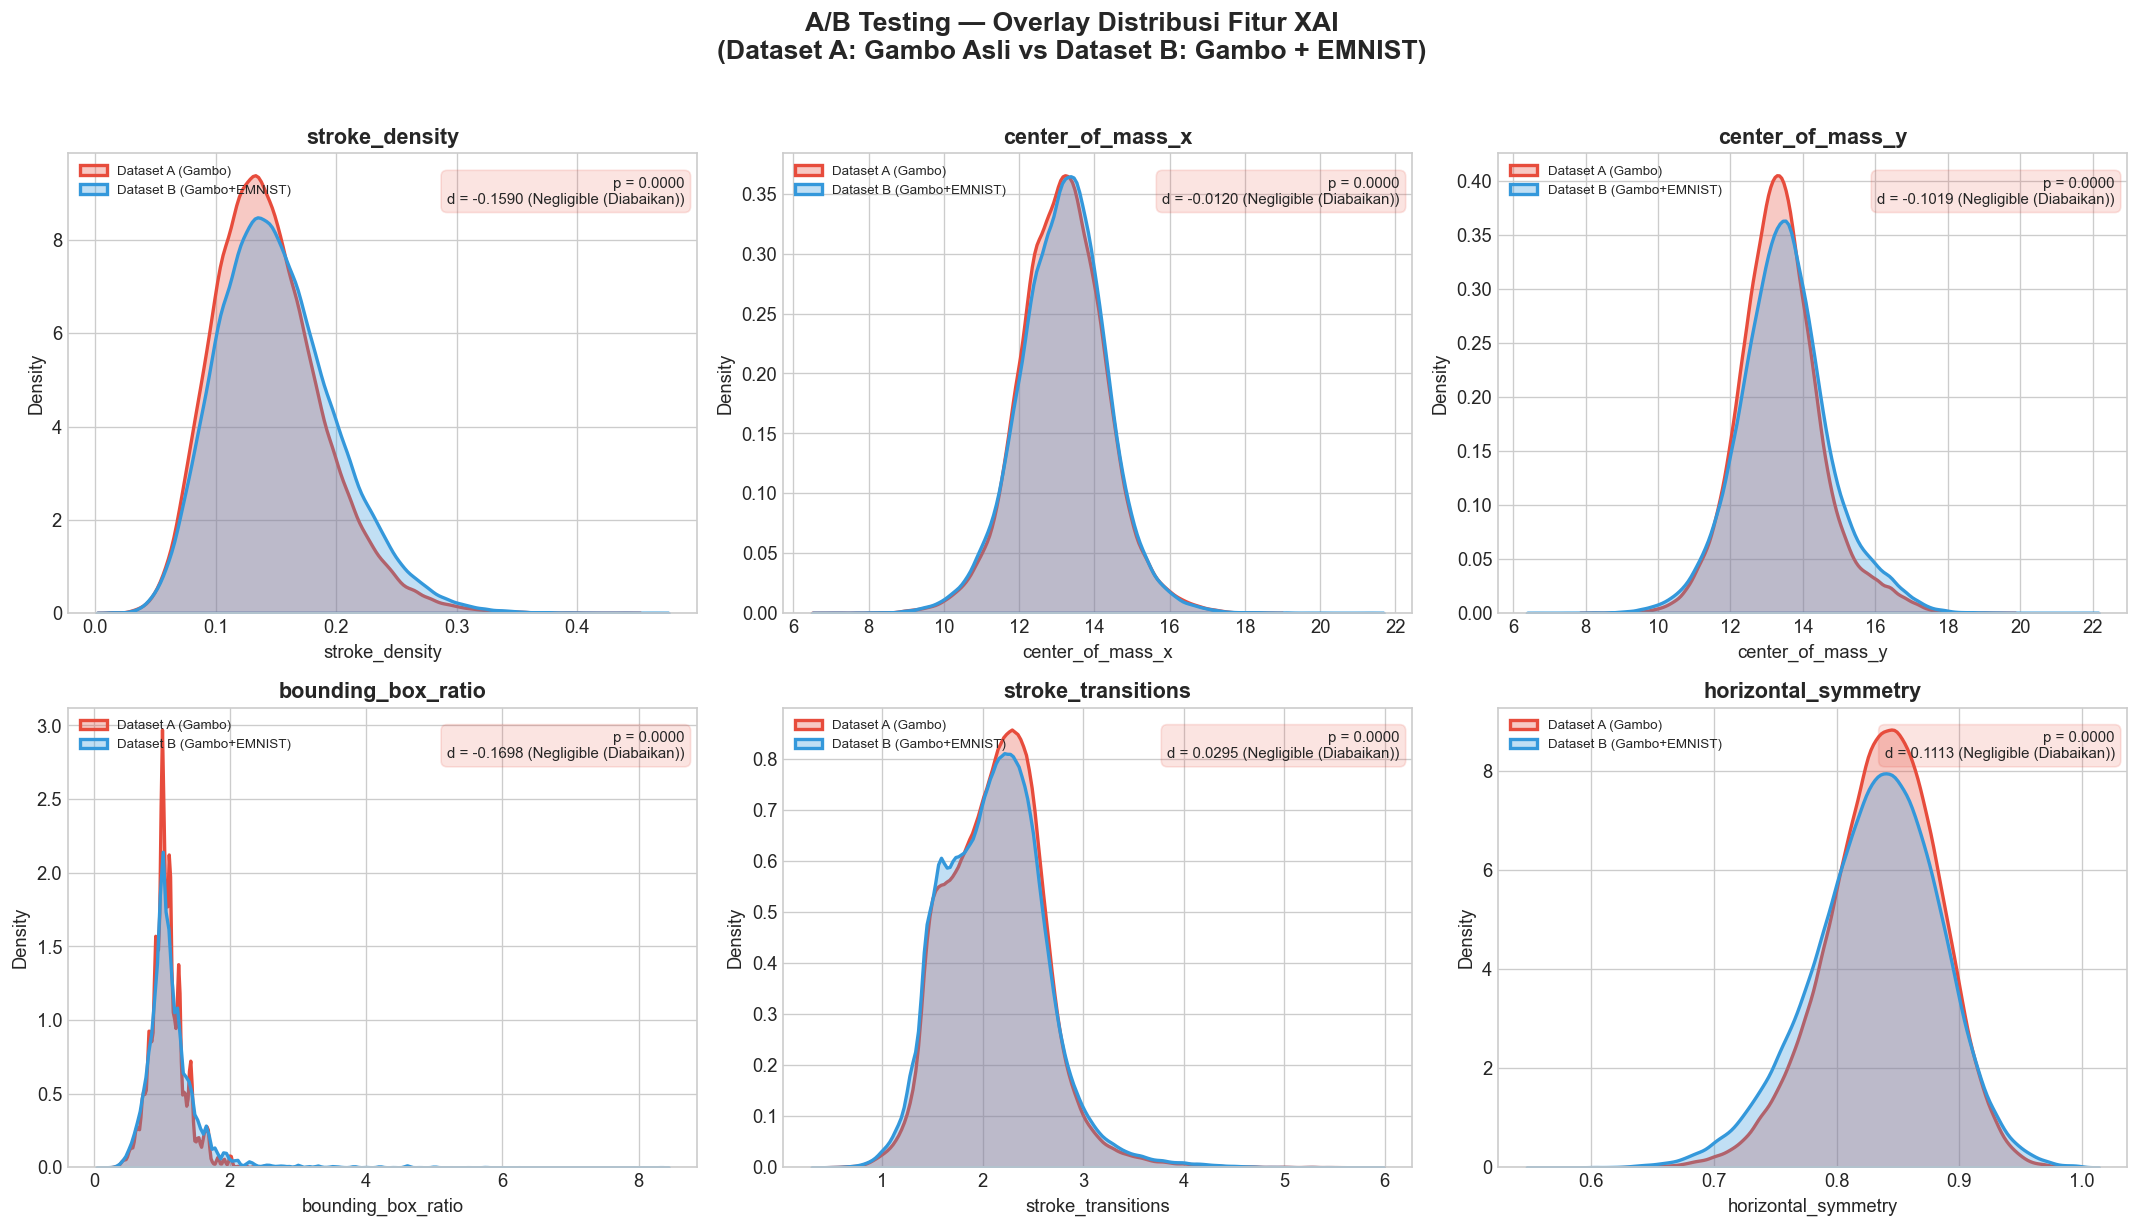

📸 Grafik disimpan ke: assets/ab_testing_kde_overlay.png


In [11]:
# =============================================
# VISUALISASI OVERLAY KDE: DATASET A vs B
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'A/B Testing — Overlay Distribusi Fitur XAI\n(Dataset A: Gambo Asli vs Dataset B: Gambo + EMNIST)',
    fontsize=16, fontweight='bold', y=1.02
)

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]

    val_A = df_A[feature].dropna()
    val_B = df_B[feature].dropna()

    # KDE Plot overlay
    sns.kdeplot(val_A, ax=ax, label='Dataset A (Gambo)', color='#E74C3C', fill=True, alpha=0.3, linewidth=2)
    sns.kdeplot(val_B, ax=ax, label='Dataset B (Gambo+EMNIST)', color='#3498DB', fill=True, alpha=0.3, linewidth=2)

    # Ambil hasil uji untuk anotasi
    row = df_results[df_results['Fitur XAI'] == feature].iloc[0]
    effect_row = df_effect[df_effect['Fitur XAI'] == feature].iloc[0]

    # Anotasi p-value & effect size
    status_color = '#27AE60' if row['P-Value'] > alpha else '#E74C3C'
    ax.text(
        0.98, 0.95,
        f"p = {row['P-Value']:.4f}\nd = {effect_row['Cohens_d']:.4f} ({effect_row['Magnitude']})",
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=status_color, alpha=0.15, edgecolor=status_color)
    )

    ax.set_title(feature, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('../assets/ab_testing_kde_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 Grafik disimpan ke: assets/ab_testing_kde_overlay.png")

## 8.9 Tabel Ringkasan Hasil & Verdict Final

Bagian ini menggabungkan hasil P-Value dan Effect Size ke dalam satu tabel keputusan akhir. Logika *verdict* menggunakan pendekatan **dual-criteria**: sebuah perbedaan baru dianggap "berbahaya" jika signifikan secara statistik DAN bermakna secara praktis.

In [12]:
# =============================================
# TABEL RINGKASAN GABUNGAN (P-Value + Effect Size)
# =============================================
df_summary = pd.merge(df_results, df_effect, on='Fitur XAI')

def final_verdict(row):
    """
    Keputusan bisnis akhir berdasarkan kombinasi P-Value DAN Effect Size.
    - Jika P-Value > α → Distribusi identik, AMAN.
    - Jika P-Value ≤ α TAPI Effect Size Negligible → Perbedaan secara statistik
      terdeteksi, namun secara praktis TIDAK bermakna (AMAN).
    - Jika P-Value ≤ α DAN Effect Size ≥ Small → BERBAHAYA, perlu investigasi.
    """
    if row['P-Value'] > alpha:
        return "✅ AMAN (Distribusi Identik)"
    elif abs(row['Cohens_d']) < 0.2:
        return "✅ AMAN (Perbedaan Statistik Saja, Praktis Negligible)"
    else:
        return "⚠️ PERLU INVESTIGASI (Perbedaan Praktis Terdeteksi)"

df_summary['Verdict Final'] = df_summary.apply(final_verdict, axis=1)

# Tampilkan tabel final
display_cols = ['Fitur XAI', 'P-Value', 'Cohens_d', 'Magnitude', 'Verdict Final']
print("\n" + "=" * 100)
print("TABEL RINGKASAN A/B TESTING — KEPUTUSAN FINAL")
print("=" * 100)
display(df_summary[display_cols])


TABEL RINGKASAN A/B TESTING — KEPUTUSAN FINAL


,Fitur XAI,P-Value,Cohens_d,Magnitude,Verdict Final
0,stroke_density,0.000000e+00,-0.159046,Negligible (Diabaikan),"✅ AMAN (Perbedaan Statistik Saja, Praktis Negl..."
1,center_of_mass_x,6.551605e-10,-0.011991,Negligible (Diabaikan),"✅ AMAN (Perbedaan Statistik Saja, Praktis Negl..."
2,center_of_mass_y,9.033247e-237,-0.101888,Negligible (Diabaikan),"✅ AMAN (Perbedaan Statistik Saja, Praktis Negl..."
3,bounding_box_ratio,6.454629e-155,-0.169816,Negligible (Diabaikan),"✅ AMAN (Perbedaan Statistik Saja, Praktis Negl..."
4,stroke_transitions,1.322933e-33,0.029513,Negligible (Diabaikan),"✅ AMAN (Perbedaan Statistik Saja, Praktis Negl..."
5,horizontal_symmetry,1.479212e-194,0.111344,Negligible (Diabaikan),"✅ AMAN (Perbedaan Statistik Saja, Praktis Negl..."


> **💡 Insight:** Tabel menunjukkan hasil yang sangat konsisten: **6 dari 6 fitur mendapat verdict "AMAN"**. Meskipun P-Value seluruhnya signifikan (efek *large N*), Cohen's d seluruhnya Negligible. Fitur dengan pergeseran terbesar pun (`bounding_box_ratio`, d = -0.1698) masih jauh di bawah ambang batas Small (0.2). Ini membuktikan bahwa EMNIST bercampur secara harmonis tanpa mendistorsi "sidik jari" asli tulisan disleksia.

## 8.10 Interpretasi Bisnis Otomatis

Bagian ini mengotomatisasi pengambilan keputusan bisnis berdasarkan hasil eksperimen, sehingga kesimpulan tidak bersifat subjektif.

In [13]:
# =============================================
# INTERPRETASI BISNIS OTOMATIS
# =============================================
total_features = len(features)
safe_count = df_summary['Verdict Final'].str.contains('AMAN').sum()
danger_count = total_features - safe_count

print("=" * 70)
print("🏁 KESIMPULAN EKSPERIMEN A/B TESTING")
print("=" * 70)
print(f"\n📊 Total Fitur XAI Diuji      : {total_features}")
print(f"✅ Fitur AMAN (Tidak Berubah) : {safe_count}")
print(f"⚠️  Fitur BERUBAH              : {danger_count}")
print(f"\n{'='*70}")

if safe_count == total_features:
    print("""
🟢 KEPUTUSAN: AUGMENTASI EMNIST DINYATAKAN AMAN.

Seluruh 6 fitur XAI menunjukkan distribusi yang identik (atau perbedaan
yang secara praktis negligible) antara Dataset A dan Dataset B.

IMPLIKASI BISNIS:
→ Injeksi dataset EMNIST berhasil menyeimbangkan rasio kelas menjadi ~1:1
  TANPA merusak karakteristik alami pola tulisan tangan disleksia.
→ Dataset B (Gambo + EMNIST) dinyatakan LAYAK untuk digunakan sebagai
  dataset pelatihan model AI (handover ke AI Engineer).
→ Risiko Majority Class Bias telah berhasil dimitigasi.
""")
elif safe_count >= (total_features * 0.5):
    print(f"""
🟡 KEPUTUSAN: AUGMENTASI EMNIST DITERIMA DENGAN CATATAN.

Mayoritas fitur ({safe_count}/{total_features}) menunjukkan distribusi identik,
namun {danger_count} fitur menunjukkan perubahan yang perlu diperhatikan.

IMPLIKASI BISNIS:
→ Dataset B masih bisa digunakan, namun AI Engineer wajib melakukan
  monitoring khusus pada fitur yang terdeteksi berubah.
→ Disarankan menambahkan class_weight pada training untuk kompensasi.
""")
else:
    print(f"""
🔴 KEPUTUSAN: AUGMENTASI EMNIST DITOLAK.

Mayoritas fitur ({danger_count}/{total_features}) menunjukkan perubahan distribusi
yang signifikan secara praktis.

IMPLIKASI BISNIS:
→ Injeksi EMNIST terbukti merusak karakteristik alami dataset.
→ Kembali ke Dataset A dan gunakan teknik alternatif (class_weight,
  oversampling internal, atau pengumpulan data tambahan).
""")

print("=" * 70)

🏁 KESIMPULAN EKSPERIMEN A/B TESTING

📊 Total Fitur XAI Diuji      : 6
✅ Fitur AMAN (Tidak Berubah) : 6
⚠️  Fitur BERUBAH              : 0


🟢 KEPUTUSAN: AUGMENTASI EMNIST DINYATAKAN AMAN.

Seluruh 6 fitur XAI menunjukkan distribusi yang identik (atau perbedaan
yang secara praktis negligible) antara Dataset A dan Dataset B.

IMPLIKASI BISNIS:
→ Injeksi dataset EMNIST berhasil menyeimbangkan rasio kelas menjadi ~1:1
  TANPA merusak karakteristik alami pola tulisan tangan disleksia.
→ Dataset B (Gambo + EMNIST) dinyatakan LAYAK untuk digunakan sebagai
  dataset pelatihan model AI (handover ke AI Engineer).
→ Risiko Majority Class Bias telah berhasil dimitigasi.



## 8.11 Catatan Metodologi

### Mengapa Effect Size (Cohen's d) Krusial?

Pada dataset berukuran ratusan ribu sampel (N > 100.000), uji statistik seperti Mann-Whitney U memiliki *statistical power* yang sangat tinggi. Ini berarti bahkan **perbedaan terkecil** (misal: selisih rata-rata 0.0001) akan menghasilkan p-value < 0.05. Fenomena ini dikenal sebagai **"p-hacking by large N"**.

Oleh karena itu, keputusan bisnis **TIDAK BOLEH** didasarkan hanya pada P-Value. Kita wajib mengkombinasikannya dengan Effect Size:
- **P-Value** menjawab: *"Apakah perbedaan ini nyata secara statistik?"*
- **Cohen's d** menjawab: *"Apakah perbedaan ini cukup besar untuk bermakna secara praktis?"*

Jika P-Value signifikan TETAPI Cohen's d < 0.2 (Negligible), maka perbedaan tersebut **tidak memiliki makna praktis** dan augmentasi tetap dinyatakan aman.

### Mengapa Bukan T-Test?

T-Test mengasumsikan distribusi data normal (*Gaussian*). Hasil Shapiro-Wilk di §8.5 membuktikan bahwa **seluruh 6 fitur berdistribusi tidak normal** (p = 0.000000). Pelanggaran asumsi normalitas akan menghasilkan P-Value yang tidak valid. Mann-Whitney U Test bebas dari asumsi ini.

---

## 8.12 Kesimpulan

Eksperimen A/B Testing ini menghasilkan temuan yang sangat kuat dan konsisten:

1. **Uji Mann-Whitney U** mendeteksi perbedaan statistik pada seluruh 6 fitur (p < 0.05). Namun, ini adalah konsekuensi alami dari *statistical power* yang tinggi pada dataset berukuran 150.000+ sampel.

2. **Effect Size (Cohen's d)** membuktikan bahwa seluruh perbedaan tersebut bersifat **Negligible** (|d| < 0.2). Pergeseran rata-rata terbesar (`bounding_box_ratio`) hanya sebesar 0.06 unit — angka yang secara klinis tidak bermakna.

3. **Verdict Final: 6/6 fitur dinyatakan AMAN.** Injeksi EMNIST berhasil menyeimbangkan rasio kelas dari 3.35:1 menjadi 1.00:1 tanpa merusak "DNA" karakteristik tulisan tangan disleksia.

**Keputusan Bisnis:**
Dataset B (Gambo + EMNIST) secara resmi dinyatakan **layak** untuk di-*handover* ke tim AI Engineer sebagai dataset pelatihan model *Deep Learning*. Risiko *Majority Class Bias* telah dimitigasi secara saintifik melalui proses augmentasi yang tervalidasi.